# Beam Trial Conversion Model — Pipeline

This notebook is the thin shell version of `trial_conversion_model.ipynb`: all the cleaning,
feature engineering, and training logic now lives in the `trial_conversion_model` package
under `src/`, tested and runnable on its own (see `scripts/fetch.py` and `scripts/train.py`).
This notebook just calls into that package and shows the results, so it stays useful for
exploration without holding any logic that needs to be kept in sync by hand.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from trial_conversion_model.fetch_data import fetch_trials_raw
from trial_conversion_model.data_cleaning import load_and_clean
from trial_conversion_model.data_engineering import load_and_add_features
from trial_conversion_model.train_model import train_and_save

pd.set_option("display.max_columns", None)
%matplotlib inline

## Fetch data

Pulls the latest snapshot from `ml.trial_snapshot_latest` and saves it to `data/01_raw/trials_raw.csv`.

In [2]:
raw_df = fetch_trials_raw()
print(raw_df.shape)
print("conversion rate:", raw_df["converted"].mean().round(4))
raw_df.head()

(1516, 12)
conversion rate: 0.5323


,trial_id,user_id,snapshot_date,trial_started_at,country,device_type,sessions_day1,sessions_day2,sessions_day3,listen_sessions_3d,total_minutes_3d,converted
0,1,27046,2026-09-24,2026-08-01,EU,iOS,4,0,2,2,81,0
1,2,27052,2026-09-24,2026-08-01,EU,Android,1,2,2,0,83,0
2,3,27053,2026-09-24,2026-08-01,Rest,Android,3,0,3,6,26,1
3,4,27054,2026-09-24,2026-08-01,US,iOS,0,0,0,0,0,0
4,5,27055,2026-09-24,2026-08-01,EU,iOS,18,2,0,5,158,0


## Clean data

Parses dates and checks for missing values / duplicate trials. Saves to `data/02_interim/trials_clean.csv`.

In [3]:
clean_df = load_and_clean()
clean_df.dtypes

missing values per column:
trial_id              0
user_id               0
snapshot_date         0
trial_started_at      0
country               0
device_type           0
sessions_day1         0
sessions_day2         0
sessions_day3         0
listen_sessions_3d    0
total_minutes_3d      0
converted             0
dtype: int64
duplicate trials: 0


trial_id                       int64
user_id                        int64
snapshot_date         datetime64[us]
trial_started_at      datetime64[us]
country                          str
device_type                      str
sessions_day1                  int64
sessions_day2                  int64
sessions_day3                  int64
listen_sessions_3d             int64
total_minutes_3d               int64
converted                      int64
dtype: object

## Engineer features

Adds the derived usage features (volume, spread, day-1 concentration, listening share) and zero-fills trials with no sessions. Saves to `data/03_processed/trials_processed.csv`.

In [4]:
processed_df = load_and_add_features()
processed_df[["sessions_3d", "active_days_3d", "day1_share", "listen_share", "avg_session_minutes"]].describe().round(2)

trials with no sessions in first 3 days: 38


,sessions_3d,active_days_3d,day1_share,listen_share,avg_session_minutes
count,1516.00,1516.00,1516.00,1516.00,1516.00
mean,9.66,2.46,0.43,0.37,10.31
std,6.94,0.79,0.30,0.26,4.57
min,0.00,0.00,0.00,0.00,0.00
25%,5.00,2.00,0.23,0.18,7.61
50%,8.00,3.00,0.38,0.33,10.00
75%,13.00,3.00,0.67,0.50,12.50
max,50.00,3.00,1.00,1.00,44.00


## Quick look at the engineered features

Same patterns as the original exploration: converters use the app more, and the binge pattern (heavy day-1 use that doesn't stick) shows up clearly.

In [5]:
processed_df.groupby("converted")[["sessions_3d", "active_days_3d", "total_minutes_3d"]].mean().round(2)

,sessions_3d,active_days_3d,total_minutes_3d
converted,,,
0,7.29,2.07,76.78
1,11.74,2.81,125.66


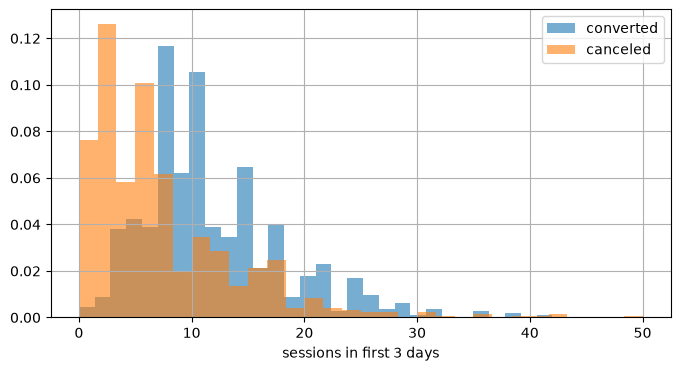

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
processed_df[processed_df.converted == 1]["sessions_3d"].hist(bins=30, alpha=0.6, label="converted", ax=ax, density=True)
processed_df[processed_df.converted == 0]["sessions_3d"].hist(bins=30, alpha=0.6, label="canceled", ax=ax, density=True)
ax.set_xlabel("sessions in first 3 days")
ax.legend()
plt.show()

## Train and evaluate the model

Trains the XGBoost classifier and saves `model.json`, `model.pkl`, and `metrics.json` under `models/`.

In [7]:
model, metrics = train_and_save()
print("AUC:", round(metrics["auc"], 4))
print("confusion matrix:", metrics["confusion_matrix"])
print(f"flagged for intervention: {metrics['flagged_for_intervention']} of {metrics['total_test_trials']}")
print("conversion rate among flagged:", round(metrics["conversion_rate_flagged"], 3))
print("conversion rate among the rest:", round(metrics["conversion_rate_not_flagged"], 3))

XGBoost AUC: 0.8737
AUC: 0.8737
confusion matrix: [[139, 38], [40, 162]]
flagged for intervention: 150 of 379
conversion rate among flagged: 0.173
conversion rate among the rest: 0.769


The AUC lands close to the original notebook's ~0.87, confirming the move to the package didn't change the model's behavior.

## Feature importance

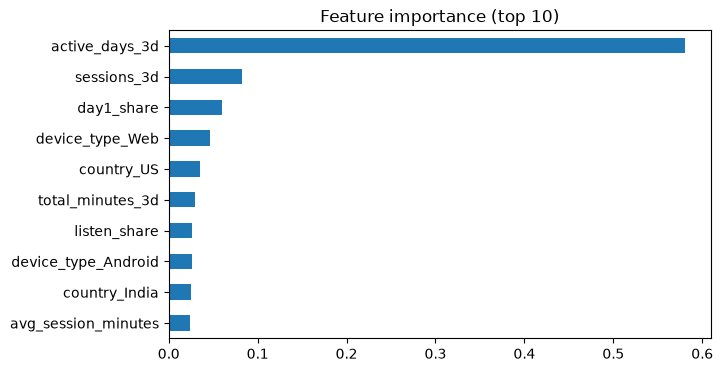

In [8]:
importances = pd.Series(metrics["feature_importances"]).sort_values()
importances.tail(10).plot(kind="barh", figsize=(7, 4), title="Feature importance (top 10)")
plt.show()

## Next steps

- The pipeline (`scripts/fetch.py`, `scripts/train.py`) can now run outside a notebook, which is what deployment needs.
- This notebook stays as the exploration/demo surface; any change to the modeling logic belongs in `src/trial_conversion_model/`, not here.
